In [8]:
# Importing packages

import requests      # Requests data from an API
import json          # Handles JSON object
import pandas as pd  # Handles data frames
import os            # Interact with the operating system

# Manage datasets
import pandas as pd

# Work with time data
import time 

# Conduct HTTP requests
import requests

# Construct tree structure of HTML data
import html5lib

# Parse HTML data obtained from scraping
from bs4 import BeautifulSoup

# Import webdriver for chrome
from webdriver_manager.chrome import ChromeDriverManager



from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager


# Automate navigating within browser (SELENIUM)
#------ Key: Manage keys
#------ Select: Obtain features from website
#------ WebDriverWait: Add wait times implicitly
#------ By: Use common information locator strategies
#------ EC and Options: Browser configuration
#------ remote.command: Check whether browser is active

from selenium import webdriver #to automate the navigating within the browser
from selenium.webdriver.chrome.service import service
from selenium.webdriver.common.keys    import Keys
from selenium.webdriver.support.ui     import Select
from selenium.webdriver.support.ui     import WebDriverWait 
from selenium.webdriver.common.by      import By
from selenium.webdriver.support        import expected_conditions as EC
from selenium.webdriver.chrome.options import Options #to use properties of the chrome webbrowser
from selenium.webdriver.remote.command import Command # Use to check whether the web driver is active

In [7]:
## Opening OpenAlex API

url_openalex_api = \
      "https://api.openalex.org/works?filter=concepts_count:%3E2" 
     


In [ ]:
### Count works with 'artificial intelligence' in the title


BASE = "https://api.openalex.org/works"
params = {
    "filter": "title.search:artificial intelligence",  # title-only search
    "per-page": 1,                                     # we only need meta.count
    "mailto": "YOUR_REAL_EMAIL@domain.com"             # use a real email
}

r = requests.get(BASE, params=params, headers={"Accept": "application/json"}, timeout=60)
print("HTTP status:", r.status_code)
print("Request URL:", r.url)
data = r.json()
print("Top-level keys:", list(data.keys()))

# Only read meta.count if it's there; otherwise show the response so we can diagnose.
if "meta" in data:
    print("Count:", data["meta"]["count"])
else:
    print("Response body (truncated):")
    print(json.dumps(data, indent=2)[:1000])

# ### Peek at some of the works
peek = requests.get(BASE, params={**params, "per-page": 25}).json()
for w in peek["results"]:
    print("-", w["display_name"])

# There are 197,544 works with "artificial intelligence" in the title.

HTTP status: 200
Request URL: https://api.openalex.org/works?filter=title.search%3Aartificial+intelligence&per-page=1&mailto=YOUR_REAL_EMAIL%40domain.com
Top-level keys: ['meta', 'results', 'group_by']
Count: 197544
- Artificial intelligence: a modern approach
- Artificial intelligence: A modern approach
- Lecture Notes in Artificial Intelligence
- Principles of Artificial Intelligence
- Proceedings of the 19th International Joint Conference on Artificial Intelligence
- High-performance medicine: the convergence of human and artificial intelligence
- Future paths for integer programming and links to artificial intelligence
- Artificial intelligence in radiology
- Artificial intelligence in healthcare: past, present and future
- Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI
- Multiagent Systems : A Modern Approach to Distributed Artificial Intelligence
- Explanation in artificial intelligence: Insights from the social

In [ ]:


from datetime import datetime

BASE = "https://api.openalex.org/works"
TERM = 'title.search:"artificial intelligence"'  # exact phrase in the TITLE
YEAR_END = datetime.now().year                   # e.g., 2025

# Build the exact query we want to send to OpenAlex
params = {
    # Filter *titles* that contain the exact phrase in TERM
    # AND restrict to publication years 2020 through YEAR_END (inclusive).
    # In OpenAlex, multiple filters are joined with commas = logical AND.
    "filter": f"{TERM},publication_year:2020-{YEAR_END}",

    # Ask OpenAlex to aggregate (group) results by the
    # country code of any author’s affiliation on each paper.
    # This field path drills into nested arrays:
    # results[].authorships[].institutions[].country_code
    "group_by": "authorships.institutions.country_code",

    # Return up to 200 grouped rows in one page (200 is the max for group_by).
    # Note the hyphen in 'per-page' — that's OpenAlex's parameter name.
    "per-page": 200,

    # Sort the grouped table by the count column, descending (largest first).
    "sort": "count:desc",

   
}

# Send the HTTP GET request. `requests` will URL-encode params and attach them as a query string.
# We also set an Accept header to explicitly ask for JSON and add a timeout for safety.
r = requests.get(
    BASE,
    params=params,
    headers={"Accept": "application/json"},
    timeout=60
)

# Raise a clear Python error if the HTTP status is not OK (e.g., 400/429/500),
# instead of silently continuing with an error payload.
r.raise_for_status()

# Parse the JSON body into Python objects (dicts/lists) so we can work with it.
data = r.json()

# Helpful for debugging: see the *exact* URL that was sent after requests added/encoded parameters.
print("Requested URL:", r.url)


# group_by returns a list of {"key": <country_code or null>, "count": <n>}
gb = pd.DataFrame(data["group_by"]).rename(columns={"key":"country_code", "count":"n"})

# drop missing/unknown country codes if present
gb = gb[gb["country_code"].notna() & (gb["country_code"] != "")]

# add share column and sort
gb["share"] = gb["n"] / gb["n"].sum()
gb = gb.sort_values("n", ascending=False).reset_index(drop=True)

gb.head(20)   # show the top 20

# If you don't have pycountry:  !pip install pycountry
try:
    import pycountry
    def code_to_name(code):
        try:
            return pycountry.countries.get(alpha_2=code).name
        except Exception:
            return code
    gb["country"] = gb["country_code"].map(code_to_name)
    gb = gb[["country_code", "country", "n", "share"]]
except Exception:
    pass

gb.head(20)


## Table for Question 2 below 


Requested URL: https://api.openalex.org/works?filter=title.search%3A%22artificial+intelligence%22%2Cpublication_year%3A2020-2025&group_by=authorships.institutions.country_code&per-page=200&sort=count%3Adesc


,country_code,key_display_name,n,share
0,https://openalex.org/countries/US,United States of America,20010,0.154340
1,https://openalex.org/countries/CN,China,15627,0.120533
2,https://openalex.org/countries/IN,India,11074,0.085415
3,https://openalex.org/countries/GB,United Kingdom of Great Britain and Northern I...,6739,0.051979
4,https://openalex.org/countries/IT,Italy,4102,0.031639
5,https://openalex.org/countries/DE,Germany,3926,0.030282
6,https://openalex.org/countries/CA,Canada,3421,0.026387
7,https://openalex.org/countries/AU,Australia,2926,0.022569
8,https://openalex.org/countries/TR,Turkey,2874,0.022168
9,https://openalex.org/countries/ES,Spain,2837,0.021882


In [ ]:


import requests, pandas as pd
from datetime import datetime

BASE   = "https://api.openalex.org/works"
MAILTO = "jeremy.anderson@emory.edu"   # <-- real email, not a placeholder
HEADERS = {
    "Accept": "application/json",
    "User-Agent": f"datasci530-hw (mailto:{MAILTO})"  # <-- IMPORTANT
}



In [18]:
r = requests.get(BASE, params={"per-page": 1, "mailto": MAILTO}, headers=HEADERS, timeout=60)
print("status:", r.status_code, "| url:", r.url)
print(r.json().keys())


status: 200 | url: https://api.openalex.org/works?per-page=1&mailto=jeremy.anderson%40emory.edu
dict_keys(['meta', 'results', 'group_by'])


In [19]:
params = {
    "filter": f'title.search:"artificial intelligence",publication_year:2020-{datetime.now().year}',
    "sort": "cited_by_count:desc",
    "per-page": 10,
    "mailto": MAILTO
}
r = requests.get(BASE, params=params, headers=HEADERS, timeout=60)
print("status:", r.status_code, "| url:", r.url)
if r.status_code != 200:
    print(r.text[:600])  # show the error message OpenAlex returns


status: 200 | url: https://api.openalex.org/works?filter=title.search%3A%22artificial+intelligence%22%2Cpublication_year%3A2020-2025&sort=cited_by_count%3Adesc&per-page=10&mailto=jeremy.anderson%40emory.edu


In [ ]:
data = r.json()
rows = []
for w in data.get("results", []):
    title = w.get("display_name")
    year  = w.get("publication_year")
    cites = w.get("cited_by_count")
    authors, insts = [], []
    for a in w.get("authorships", []):
        nm = (a.get("author") or {}).get("display_name")
        if nm: authors.append(nm)
        for inst in a.get("institutions", []):
            dn = inst.get("display_name")
            if dn: insts.append(dn)
    seen=set()
    insts = [x for x in insts if not (x in seen or seen.add(x))]
    rows.append({"title": title, "year": year, "cited_by_count": cites,
                 "authors": ", ".join(authors), "institutions": ", ".join(insts)})

top10 = pd.DataFrame(rows).sort_values("cited_by_count", ascending=False).reset_index(drop=True)
top10


##The titles of the names of the 10 most highly cited papers with "artificial intelligence" in the title published since 2020 are in the table below. 
# The citations range between 1,385 amd 2,249.
# All of the authors are associated with universities. 


,title,year,cited_by_count,authors,institutions
0,Artificial Intelligence in Education: A Review,2020,2249,"Lijia Chen, Pingping Chen, Zhijian Lin","Yango University, Fuzhou University"
1,The role of artificial intelligence in achievi...,2020,2195,"Ricardo Vinuesa, Hossein Azizpour, Iolanda Lei...","Swedish e-Science Research Centre, KTH Royal I..."
2,Using Artificial Intelligence to Detect COVID-...,2020,1956,"Lin Li, Lixin Qin, Zeguo Xu, Youbing Yin, Xin ...","Jianghan University, Wuhan Pulmonary Hospital,..."
3,Revolutionizing healthcare: the role of artifi...,2023,1629,"Shuroug A. Alowais, Sahar S. Alghamdi, Nada Al...",King Saud bin Abdulaziz University for Health ...
4,Comparing Physician and Artificial Intelligenc...,2023,1576,"John W. Ayers, Adam Poliak, Mark Dredze, Eric ...","University of California, San Diego, Qualcomm ..."
5,A Survey on Explainable Artificial Intelligenc...,2020,1560,"Erico Tjoa, Cuntai Guan","Alibaba Group (China), Nanyang Technological U..."
6,Artificial Intelligence (AI) applications for ...,2020,1414,"Raju Vaishya, Mohd Javaid, Ibrahim Haleem Khan...","Indraprastha Apollo Hospitals, Jamia Millia Is..."
7,Human Trust in Artificial Intelligence: Review...,2020,1405,"Ella Glikson, Anita Williams Woolley","Bar-Ilan University, Carnegie Mellon University"
8,Review of Artificial Intelligence Techniques i...,2020,1396,"Feng Shi, Jun Wang, Jun Shi, Ziyan Wu, Qian Wa...","United Imaging Healthcare (China), Shanghai Un..."
9,Photonics for artificial intelligence and neur...,2021,1385,"Bhavin J. Shastri, Alexander N. Tait, Thomas F...","Queen's University, Princeton University, Univ..."


term,GPT,LLM,artificial intelligence
year,,,
2016,34,60,1255
2017,24,33,2133
2018,36,63,4648
2019,41,38,8041
2020,84,56,12762
2021,138,25,16455
2022,212,49,19018
2023,1762,1631,29438
2024,2491,10201,45823


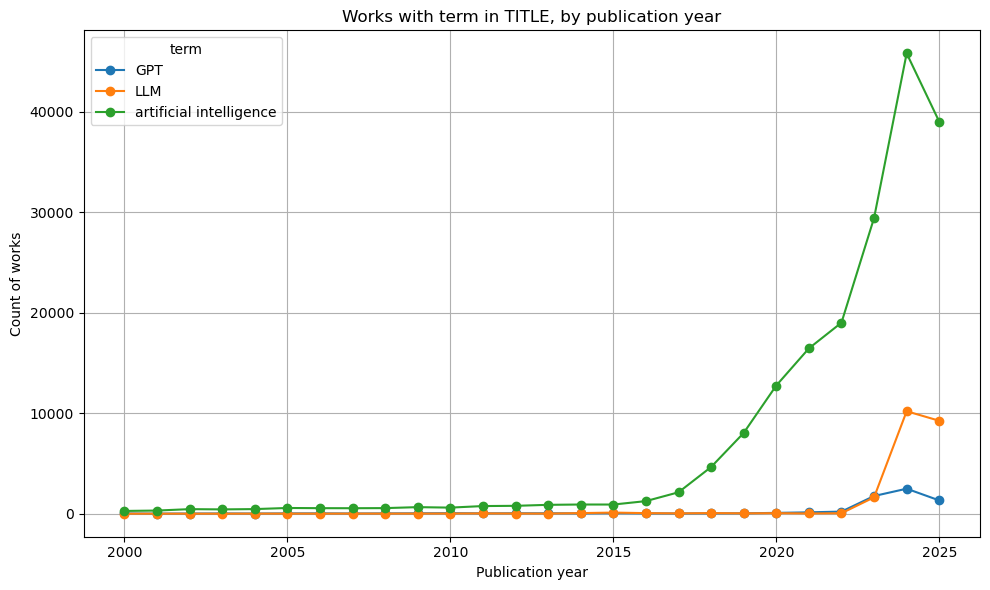

In [22]:
# --- Imports we need ---
import requests                 # to call the OpenAlex API over HTTP
import pandas as pd             # to turn JSON into tidy tables
import matplotlib.pyplot as plt # for a simple line chart
from datetime import datetime   # to get the current year

# --- API endpoint & polite usage info ---
BASE   = "https://api.openalex.org/works"                 # Works endpoint
MAILTO = "jeremy.anderson@emory.edu"                     # <— put YOUR real email
HEADERS = {                                               # a clear User-Agent helps avoid 403s
    "Accept": "application/json",
    "User-Agent": f"datasci530-hw (mailto:{MAILTO})"
}

# --- Time window for the question ---
YEAR_START = 2000                         # start of the timeline
YEAR_END   = datetime.now().year          # end at the current year

# --- Helper function: one term -> (year, count) series from OpenAlex ---
def yearly_counts_for_title(term, quoted=True):
    """
    Ask OpenAlex for a year-by-year count of works whose TITLE matches `term`.
    If quoted=True, match the exact phrase in the title (e.g., "artificial intelligence").
    Returns a DataFrame with columns: year (int), n (int), term (str).
    """
    # Build the title filter. OpenAlex is case-insensitive, quotes enforce exact phrase.
    title_filter = f'title.search:"{term}"' if quoted else f"title.search:{term}"

    # Compose all query parameters for OpenAlex
    params = {
        # Combine multiple restrictions with commas (logical AND in OpenAlex)
        "filter": f"{title_filter},publication_year:{YEAR_START}-{YEAR_END}",
        "group_by": "publication_year",  # ask server to aggregate by publication year
        "per-page": 200,                 # enough to return all years in one response
        "sort": "key:asc",               # sort the grouped rows by the year key ascending
        "mailto": MAILTO                 # polite pool contact
    }

    # Make the HTTP GET request (requests will URL-encode params for us)
    r = requests.get(BASE, params=params, headers=HEADERS, timeout=60)
    r.raise_for_status()                 # raise a clear error if not 200 OK
    data = r.json()                      # parse JSON body into Python dict

    # Convert the grouped result (list of {"key": <year>, "count": <n>}) to a DataFrame
    df = pd.DataFrame(data.get("group_by", [])) \
            .rename(columns={"key": "year", "count": "n"})

    # Ensure expected types and add a label for the term
    if not df.empty:
        df["year"] = df["year"].astype(int)
        df["n"]    = df["n"].astype(int)
        df["term"] = term
    return df

# --- Get year-by-year series for each term ---
ai  = yearly_counts_for_title("artificial intelligence", quoted=True)  # exact phrase in TITLE
llm = yearly_counts_for_title("LLM", quoted=True)                      # exact token "LLM" in TITLE
gpt = yearly_counts_for_title("GPT", quoted=True)                      # exact token "GPT" in TITLE

# (Optional) If you want broader matches for LLM/GPT, set quoted=False above,
# but be aware you will pick up non-AI meanings too (e.g., Master of Laws for LLM,
# an enzyme formerly abbreviated GPT in biomed).

# --- Stack them together and pivot to a wide table (years as index, terms as columns) ---
all_series = pd.concat([ai, llm, gpt], ignore_index=True)
wide = all_series.pivot(index="year", columns="term", values="n").fillna(0).astype(int)

# Peek at the last few rows to confirm the shape
display(wide.tail(10))

# --- Plot the three series over time ---
ax = wide.plot(figsize=(10, 6), marker="o")     # simple multi-line plot
ax.set_title("Works with term in TITLE, by publication year")
ax.set_xlabel("Publication year")
ax.set_ylabel("Count of works")
ax.grid(True)
plt.tight_layout()
plt.show()


,year,key_display_name,n,term
5,2016,2016,10,Sports Analytics
6,2017,2017,12,Sports Analytics
7,2018,2018,23,Sports Analytics
8,2019,2019,36,Sports Analytics
9,2020,2020,17,Sports Analytics
10,2021,2021,12,Sports Analytics
11,2022,2022,19,Sports Analytics
12,2023,2023,22,Sports Analytics
13,2024,2024,47,Sports Analytics
14,2025,2025,29,Sports Analytics


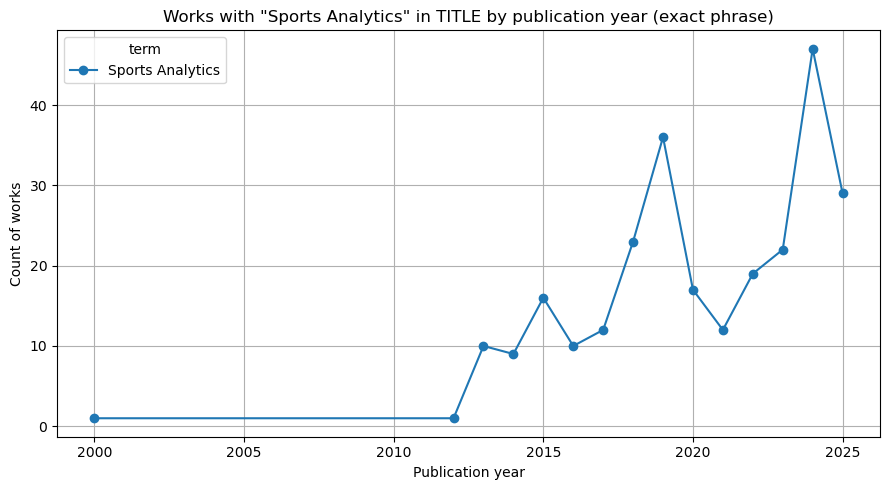

In [25]:
# --- Imports (used for the request, table, and plot) ---
import requests                 # HTTP calls to OpenAlex
import pandas as pd             # tidy tables
import matplotlib.pyplot as plt # simple plotting
from datetime import datetime   # current year for the range

# --- Reuse your earlier constants (define if you haven't already) ---
BASE   = "https://api.openalex.org/works"           # Works endpoint
MAILTO = "jeremy.anderson@emory.edu"               # <-- put YOUR real email
HEADERS = {                                         # explicit headers help avoid 403s
    "Accept": "application/json",
    "User-Agent": f"datasci530-hw (mailto:{MAILTO})"
}

YEAR_START = 2000                  # start year for the analysis window
YEAR_END   = datetime.now().year   # end at current year (updates automatically)

# === Choose your NEW keyword here ===
NEW_TERM = "Sports Analytics"   # <-- change to anything you want

# If you want exact phrase matching in TITLES, keep quoted=True.
# Set quoted=False to match titles that contain the words anywhere (broader, noisier).
QUOTED = True

# --- Helper: fetch year-by-year counts for a TITLE term from OpenAlex ---
def yearly_counts_for_title(term, quoted=True, y0=YEAR_START, y1=YEAR_END):
    """
    Returns a DataFrame with columns [year, n, term] for works whose TITLE matches `term`
    between years y0..y1 (inclusive), using server-side group_by=publication_year.
    quoted=True -> exact phrase (e.g., "reinforcement learning")
    quoted=False -> broader token match (words anywhere in the title)
    """
    # Build the title filter (OpenAlex is case-insensitive; quotes enforce exact phrase)
    title_filter = f'title.search:"{term}"' if quoted else f"title.search:{term}"

    # Compose query params (comma = logical AND for filters in OpenAlex)
    params = {
        "filter": f"{title_filter},publication_year:{y0}-{y1}",
        "group_by": "publication_year",   # return one row per year with a 'count'
        "per-page": 200,                  # enough to return all years at once
        "sort": "key:asc",                # order by the year key ascending
        "mailto": MAILTO
    }

    # Make the HTTP request
    r = requests.get(BASE, params=params, headers=HEADERS, timeout=60)
    r.raise_for_status()                  # raise an error if not 200 OK
    data = r.json()                       # parse JSON -> Python dict

    # Convert the grouped list ({key:year, count:n}) into a DataFrame
    df = pd.DataFrame(data.get("group_by", [])) \
           .rename(columns={"key": "year", "count": "n"})

    # Clean types & label with the searched term
    if not df.empty:
        df["year"] = df["year"].astype(int)
        df["n"]    = df["n"].astype(int)
        df["term"] = term
    return df

# --- Run the analysis for your NEW keyword ---
new_series = yearly_counts_for_title(NEW_TERM, quoted=QUOTED)

# Sanity check: show the last few years
display(new_series.tail(10))

# --- Pivot to wide (optional) and make a plot ---
# For a single series we can plot directly, but pivot keeps the pattern consistent.
wide = new_series.pivot(index="year", columns="term", values="n").fillna(0).astype(int)

# Plot the trend for your chosen term
ax = wide.plot(figsize=(9, 5), marker="o")
ax.set_title(f'Works with "{NEW_TERM}" in TITLE by publication year'
             + (" (exact phrase)" if QUOTED else " (broad match)"))
ax.set_xlabel("Publication year")
ax.set_ylabel("Count of works")
ax.grid(True)
plt.tight_layout()
plt.show()

# Optional: save the table for your write-up
# wide.to_csv(f'yearly_counts_{NEW_TERM.replace(" ", "_")}.csv')
